# Lezione 1 — Classificazione fine-grained e fusione immagine + tabella

**Modulo 1.** Corso di AI applicata, Zucchetti Centro Sistemi.

Il notebook si esegue dall'alto in basso. Tre celle sono marcate `PUNTO DI VARIAZIONE`:
contengono una costante che si modifica e si riesegue per confrontare i risultati.

### Dati

**CUB-200-2011**, sottoinsieme di 20 classi: 8 gabbiani, 7 sterne, 5 martin pescatori.

> Wah C., Branson S., Welinder P., Perona P., Belongie S.
> *The Caltech-UCSD Birds-200-2011 Dataset.*
> Computation & Neural Systems Technical Report CNS-TR-2011-001,
> California Institute of Technology, 2011.

Fonte: <https://www.vision.caltech.edu/datasets/cub_200_2011/>.
I termini della fonte limitano l'uso a ricerca e didattica non commerciali. Questo
sottoinsieme è ridistribuito per la didattica di questo corso e non va usato per scopi
commerciali. Le immagini non compaiono nel PDF delle slide.

In [1]:
import os, tarfile, urllib.request, pathlib, math, warnings
warnings.filterwarnings("ignore")

URL = ("https://github.com/nunziati/zcs-ai-course-2026/releases/download/"
       "dati-cub/cub-200-2011-20-classi.tgz")
ROOT = pathlib.Path("dati")

if not (ROOT / "CUB_200_2011" / "images.txt").exists():
    ROOT.mkdir(exist_ok=True)
    print("download del dataset, 65 MB")
    urllib.request.urlretrieve(URL, ROOT / "cub.tgz")
    with tarfile.open(ROOT / "cub.tgz") as t:
        t.extractall(ROOT)

D = ROOT / "CUB_200_2011"

import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cpu":
    torch.set_num_threads(os.cpu_count())
print(f"torch {torch.__version__}, device {DEVICE}")
if DEVICE == "cpu":
    print("Senza GPU il notebook gira comunque. Per accenderla su Colab:")
    print("Runtime > Cambia tipo di runtime > T4.")

torch 2.13.0+cpu, device cpu
Senza GPU il notebook gira comunque. Per accenderla su Colab:
Runtime > Cambia tipo di runtime > T4.


---

# Passo 2 — Dati

In [2]:
images = pd.read_csv(D/"images.txt", sep=" ", names=["id", "file"])
labels = pd.read_csv(D/"image_class_labels.txt", sep=" ", names=["id", "classe"])
split  = pd.read_csv(D/"train_test_split.txt", sep=" ", names=["id", "train"])
classi = pd.read_csv(D/"classes.txt", sep=" ", names=["classe", "nome"])

dati = images.merge(labels, on="id").merge(split, on="id").merge(classi, on="classe")

# Gli id di classe originali non sono contigui: 59-66, 79-83, 141-147.
# Senza rimappatura la cross-entropy si aspetta 148 classi.
dati["y"], nomi_classe = pd.factorize(dati["nome"].sort_values().values, sort=True)
dati = dati.sort_values("nome").reset_index(drop=True)

print(f"{len(dati)} immagini, {len(nomi_classe)} classi")
print(f"train {int(dati.train.sum())}, test {int((1-dati.train).sum())}")
print(f"id di classe originali: {sorted(dati.classe.unique().tolist())}")
print(f"rimappati in 0..{dati.y.max()}")

1187 immagini, 20 classi
train 599, test 588
id di classe originali: [59, 60, 61, 62, 63, 64, 65, 66, 79, 80, 81, 82, 83, 141, 142, 143, 144, 145, 146, 147]
rimappati in 0..19


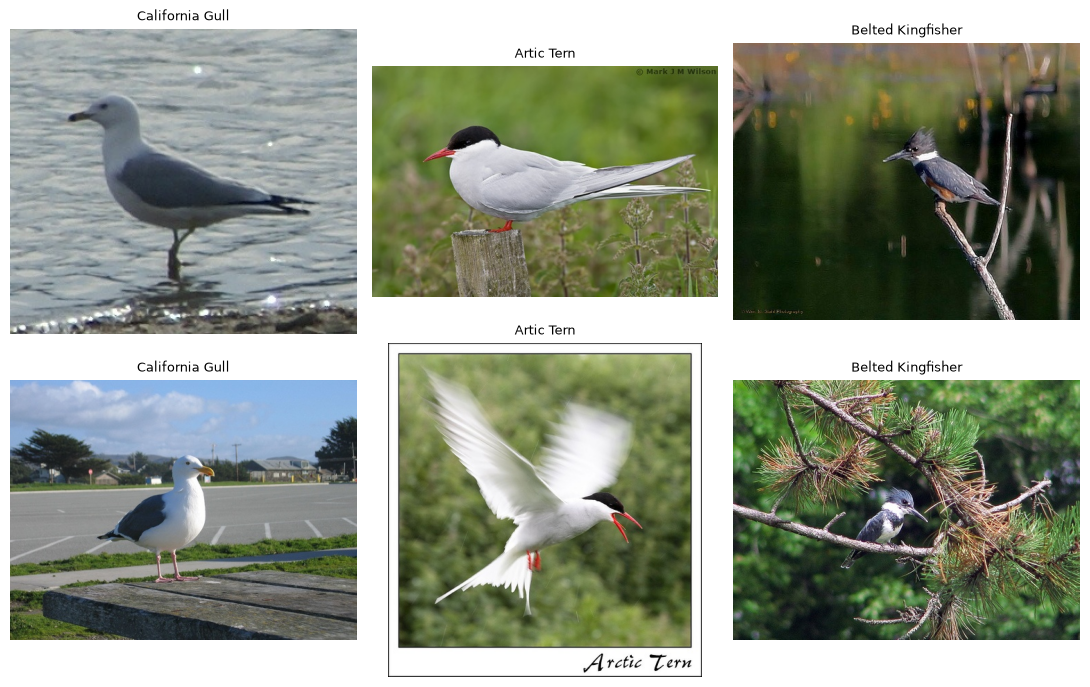

In [3]:
scelte = [dati[dati.nome.str.contains(g)].iloc[i]
          for g in ("Gull", "Tern", "Kingfisher") for i in (0, 40)]
fig, assi = plt.subplots(2, 3, figsize=(11, 7))
for a, r in zip(assi.T.ravel(), scelte):
    a.imshow(Image.open(D/"images"/r.file)); a.axis("off")
    a.set_title(r.nome.split(".")[1].replace("_", " "), fontsize=9)
plt.tight_layout(); plt.show()

## Attributi e geometria

Il dataset contiene 312 attributi visivi — `has_bill_shape::dagger`, `has_wing_color::white` —
distribuiti su due file con nomi simili e contenuto diverso. La cella seguente misura
entrambi.

In [4]:
from sklearn.linear_model import LogisticRegression
m = dati.train.values == 1

# (a) per classe: una riga per specie, identica per tutte le sue immagini
per_classe = np.array([list(map(float, r.split()))
                       for r in open(D/"attributes/class_attribute_labels_continuous.txt")])
Xa = per_classe[dati.y.values]
a1 = 100 * LogisticRegression(max_iter=3000).fit(Xa[m], dati.y[m]).score(Xa[~m], dati.y[~m])
print(f"(a) attributi per classe    accuracy {a1:.1f}%")
print(f"    righe distinte: {len(np.unique(per_classe, axis=0))} per {len(nomi_classe)} classi")

# (b) per immagine: quello che l'annotatore ha marcato su quella foto
attr = pd.read_csv(D/"attributes/image_attribute_labels.txt", sep=" ",
                   usecols=[0, 1, 2], names=["id", "attr", "presente"], on_bad_lines="skip")
Xb = attr.pivot_table(index="id", columns="attr", values="presente",
                      fill_value=0).reindex(dati.id.values).fillna(0)
a2 = 100 * LogisticRegression(max_iter=3000).fit(Xb[m], dati.y[m]).score(Xb[~m], dati.y[~m])
print(f"(b) attributi per immagine  accuracy {a2:.1f}%")

(a) attributi per classe    accuracy 100.0%
    righe distinte: 20 per 20 classi


(b) attributi per immagine  accuracy 55.3%


Il file per classe ha venti righe distinte per venti classi, quindi determina l'etichetta.
Usarlo come feature produce un classificatore perfetto che non ha imparato nulla
dall'immagine.

Il file per immagine è legittimo e ottiene circa il 55%, sotto quello che ottiene la sola
immagine. Sono annotazioni umane, con la variabilità che ne consegue.

Nessuno dei due corrisponde al caso ZCS, dove il vettore numerico è una misura strumentale
e non una descrizione dell'oggetto già riconosciuto. Il vettore che useremo è geometrico,
costruito dalle coordinate delle parti annotate e dal bounding box.

In [5]:
parti = pd.read_csv(D/"parts/part_locs.txt", sep=" ",
                    names=["id", "parte", "x", "y", "visibile"])
box = pd.read_csv(D/"bounding_boxes.txt", sep=" ", names=["id", "bx", "by", "bw", "bh"])

BECCO, PANCIA, PETTO, CORONA, FRONTE, NUCA, CODA, GOLA = 2, 3, 4, 5, 6, 10, 14, 15
PARTI = [BECCO, PANCIA, PETTO, CORONA, FRONTE, NUCA, CODA, GOLA]

# Ali e occhi sono annotati rispettivamente nel 65% e nel 50% delle immagini, quindi
# restano fuori. Le otto parti selezionate sono annotate in oltre il 90% dei casi.
viste = parti[parti.visibile == 1]
P = {p: viste[viste.parte == p].set_index("id")[["x", "y"]] for p in PARTI}
B = box.set_index("id")

def dist(a, b, ids):
    pa, pb = P[a].reindex(ids), P[b].reindex(ids)
    return np.hypot(pa.x - pb.x, pa.y - pb.y).values

ids = dati.id.values
bw, bh = B.reindex(ids).bw.values, B.reindex(ids).bh.values
dim = np.array([Image.open(D/"images"/f).size for f in dati.file])
corpo = dist(BECCO, CODA, ids)
r = lambda a, b: dist(a, b, ids) / corpo

G = pd.DataFrame({
    # in pixel: dipendono dalla distanza di ripresa
    "corpo_px": corpo,
    "sqrt_area_box_px": np.sqrt(bw * bh),
    # rapporti: invarianti alla distanza di ripresa
    "corpo_su_diagonale": corpo / np.hypot(bw, bh),
    "becco_su_corpo": r(BECCO, FRONTE),
    "testa_su_corpo": r(CORONA, GOLA),
    "becco_nuca_su_corpo": r(BECCO, NUCA),
    "petto_pancia_su_corpo": r(PETTO, PANCIA),
    "gola_coda_su_corpo": r(GOLA, CODA),
    "corona_fronte_su_corpo": r(CORONA, FRONTE),
    "box_aspetto": bw / bh,
    "box_su_immagine": (bw * bh) / (dim[:, 0] * dim[:, 1]),
    "parti_visibili": sum(P[p].reindex(ids).x.notna().values for p in PARTI) / len(PARTI),
})
print(f"{G.shape[1]} misure per immagine")
print("\nmissing per feature, in percentuale:")
print((100 * G.isna().mean()).round(1).to_string())

12 misure per immagine

missing per feature, in percentuale:
corpo_px                   2.5
sqrt_area_box_px           0.0
corpo_su_diagonale         2.5
becco_su_corpo             4.3
testa_su_corpo             5.1
becco_nuca_su_corpo        5.7
petto_pancia_su_corpo     11.3
gola_coda_su_corpo         4.0
corona_fronte_su_corpo     5.2
box_aspetto                0.0
box_su_immagine            0.0
parti_visibili             0.0


In [6]:
# Imputazione con la mediana del training set, poi standardizzazione con media e
# deviazione standard del solo training set.
G = G.fillna(G[m].median())
Gz = ((G - G[m].mean()) / (G[m].std() + 1e-8)).astype("float32")

clf = LogisticRegression(max_iter=2000).fit(Gz[m], dati.y[m])
print(f"accuracy sulle sole {G.shape[1]} misure: {100*clf.score(Gz[~m], dati.y[~m]):.1f}%")
print(f"riferimento casuale: {100/len(nomi_classe):.0f}%")

accuracy sulle sole 12 misure: 24.1%
riferimento casuale: 5%


Le prime due misure sono in pixel e dipendono dalla distanza di ripresa: approssimano la
dimensione reale invece di misurarla. Nel caso ZCS le misure provengono da uno strumento e
sono in millimetri, quindi il vincolo non si applica.

## Augmentation sotto acquisizione controllata

L'acquisizione ZCS avviene su piano fisso, con illuminazione calibrata e un oggetto per
scatto. Le trasformazioni che simulano variazioni assenti dal dominio di produzione
consumano capacità del modello senza contropartita.

---

# Passo 3 — Dalla baseline al metodo

ZCS ha in produzione una EfficientNet con layer ArcFace su oltre 700 categorie. La domanda
operativa riguarda quindi cosa modificare su un sistema ArcFace esistente, in ordine di
costo crescente:

1. un iperparametro: margine e scala;
2. la regola di decisione, a rappresentazione invariata;
3. il dato, con la fusione delle misure numeriche.

Il backbone resta congelato e le sue uscite vengono calcolate e mantenute in memoria: 1187
vettori da 1280 componenti. Ogni esperimento allena solo la head sui 599 vettori di
training. Il numero di riferimento per la produzione viene da un fine-tuning completo, che
resta fuori da questo notebook.

In [7]:
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

pesi = EfficientNet_B0_Weights.IMAGENET1K_V1
rete = efficientnet_b0(weights=pesi).eval().to(DEVICE)
backbone = nn.Sequential(rete.features, rete.avgpool, nn.Flatten()).eval()
for q in backbone.parameters():
    q.requires_grad_(False)

prep = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

pezzi, batch = [], []
for n, f in enumerate(dati.file, 1):
    batch.append(prep(Image.open(D/"images"/f).convert("RGB")))
    if len(batch) == 32 or n == len(dati):
        with torch.no_grad():
            pezzi.append(backbone(torch.stack(batch).to(DEVICE)).cpu())
        batch = []

E = torch.cat(pezzi)
tr = torch.tensor(dati.train.values == 1)
Y  = torch.tensor(dati.y.values).long()
Gt = torch.tensor(Gz.values)
Xtr, Xte = E[tr], E[~tr]
Gtr, Gte = Gt[tr], Gt[~tr]
ytr, yte = Y[tr], Y[~tr]
NCLASSI = len(nomi_classe)
print(f"embedding: {E.shape[0]} x {E.shape[1]}")
print(f"train {len(ytr)}, test {len(yte)}")

embedding: 1187 x 1280
train 599, test 588


In [8]:
class ArcFace(nn.Module):
    def __init__(self, dim, classi, margine=0.5, scala=32.0):
        super().__init__()
        self.W = nn.Parameter(torch.randn(classi, dim) * 0.01)
        self.margine, self.scala = margine, scala

    def forward(self, x, y=None):
        # embedding e pesi normalizzati: il logit coincide con il coseno dell'angolo
        cos = F.linear(F.normalize(x), F.normalize(self.W)).clamp(-1 + 1e-7, 1 - 1e-7)
        if y is None or self.margine == 0:
            return self.scala * cos                       # inferenza: nessun margine
        # training: il margine si somma all'angolo della sola classe corretta
        angolo = cos.acos() + F.one_hot(y, cos.shape[1]) * self.margine
        return self.scala * angolo.cos()


class Head(nn.Module):
    # bottleneck + head. iniezione: niente | prima | dopo
    def __init__(self, dim_in, dim_geo=0, dim_bott=128, arcface=True,
                 margine=0.5, scala=32.0, iniezione="niente"):
        super().__init__()
        self.iniezione, self.arcface = iniezione, arcface
        dp = 32
        self.proj = (nn.Sequential(nn.Linear(dim_geo, dp), nn.ReLU(), nn.Linear(dp, dp))
                     if dim_geo else None)
        ingresso = dim_in + (dp if iniezione == "prima" else 0)
        self.bott = nn.Sequential(nn.Linear(ingresso, dim_bott), nn.BatchNorm1d(dim_bott))
        uscita = dim_bott + (dp if iniezione == "dopo" else 0)
        self.head = (ArcFace(uscita, NCLASSI, margine, scala) if arcface
                     else nn.Linear(uscita, NCLASSI))

    def embedding(self, x, g=None):
        p = self.proj(g) if self.proj is not None else None
        if self.iniezione == "prima":
            x = torch.cat([x, p], 1)
        z = self.bott(x)
        if self.iniezione == "dopo":
            z = torch.cat([z, p], 1)
        return z

    def forward(self, x, g=None, y=None):
        z = self.embedding(x, g)
        return self.head(z, y) if self.arcface else self.head(z)


def allena(modello, X, Y_, G=None, epoche=60, lr=1e-3, seed=0):
    torch.manual_seed(seed)
    opt = torch.optim.AdamW(modello.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epoche)
    storia = []
    for _ in range(epoche):
        modello.train(); idx = torch.randperm(len(Y_)); tot = 0.0
        for k in range(0, len(idx), 64):
            b = idx[k:k+64]
            if len(b) < 2:
                continue
            opt.zero_grad()
            loss = F.cross_entropy(modello(X[b], G[b] if G is not None else None, Y_[b]),
                                   Y_[b], label_smoothing=0.1)
            loss.backward(); opt.step(); tot += loss.item() * len(b)
        sched.step(); storia.append(tot / len(Y_))
    return storia


@torch.no_grad()
def predici(modello, X, G=None):
    modello.eval(); return modello(X, G).argmax(1)

@torch.no_grad()
def embeddings(modello, X, G=None):
    modello.eval(); return F.normalize(modello.embedding(X, G))

def accuracy(p, y): return 100 * (p == y).float().mean().item()

In [9]:
def mcnemar(pred_a, pred_b, y):
    # Confronto di due modelli sullo stesso test set: contano solo i disaccordi.
    ok_a, ok_b = (pred_a == y), (pred_b == y)
    solo_a = int((ok_a & ~ok_b).sum())
    solo_b = int((ok_b & ~ok_a).sum())
    n = solo_a + solo_b
    if n == 0:
        return solo_a, solo_b, 1.0
    chi = (abs(solo_a - solo_b) - 1) ** 2 / n           # correzione di continuita'
    return solo_a, solo_b, math.erfc(math.sqrt(chi / 2))

def confronta(nome, pred_new, pred_rif, y=None):
    y = yte if y is None else y
    riga = f"{nome:44} {accuracy(pred_new, y):6.2f}%"
    if pred_rif is not None:
        a, b, p = mcnemar(pred_rif, pred_new, y)
        riga += (f"   +{b:2d} -{a:2d}  disaccordi {a+b:3d}  p={p:.3f}"
                 f"   {'significativo' if p < 0.05 else 'entro il rumore'}")
    print(riga)

def su_tre_seed(fabbrica, X=None, G=None):
    X = Xtr if X is None else X
    acc, pr = [], []
    for seed in (0, 1, 2):
        mod = fabbrica(); allena(mod, X, ytr, G, seed=seed)
        p = predici(mod, Xte, Gte if G is not None else None)
        acc.append(accuracy(p, yte)); pr.append(p)
    return float(np.mean(acc)), float(np.std(acc)), pr[0]

## Baseline: softmax e ArcFace sulla stessa rappresentazione

In [10]:
a_soft, s_soft, p_soft = su_tre_seed(lambda: Head(1280, arcface=False))
a_arc,  s_arc,  p_arc  = su_tre_seed(lambda: Head(1280, arcface=True, margine=0.5))

print(f"softmax, label smoothing 0.1     accuracy {a_soft:6.2f}%   sd sul seed {s_soft:.2f}")
print(f"ArcFace, margine 0.5 scala 32    accuracy {a_arc:6.2f}%   sd sul seed {s_arc:.2f}")
print()
confronta("confronto sul seed 0", p_arc, p_soft)
print(f"\nDifferenza fra le due head: {abs(a_arc-a_soft):.2f} punti.")
print(f"Variazione dovuta alla sola inizializzazione: {max(s_soft,s_arc):.2f} punti.")

softmax, label smoothing 0.1     accuracy  67.63%   sd sul seed 0.63
ArcFace, margine 0.5 scala 32    accuracy  67.40%   sd sul seed 0.21

confronto sul seed 0                          67.35%   +30 -27  disaccordi  57  p=0.791   entro il rumore

Differenza fra le due head: 0.23 punti.
Variazione dovuta alla sola inizializzazione: 0.63 punti.


Le due head ottengono la stessa accuracy entro il rumore. Con backbone congelato e 599
vettori di training il margine angolare non dispone di dati sufficienti a costruire una
geometria migliore di quella del softmax.

Il criterio applicabile in produzione è quello usato qui: la riga dei disaccordi e il
p-value, non il confronto diretto fra le due percentuali.

## Margine e scala

Il margine ArcFace si somma all'angolo ed è espresso in radianti: `0.5` corrisponde a 28,6
gradi. Il margine CosFace si sottrae al coseno ed è adimensionale. I due valori appartengono
a scale diverse e non sono intercambiabili.

All'inizializzazione gli embedding sono quasi ortogonali ai vettori di classe, quindi il
logit della classe corretta vale `scala · cos(90° + margine)` e gli altri valgono zero.

All'inizializzazione gli embedding sono quasi ortogonali ai vettori di classe, quindi il
logit della classe corretta vale `scala · cos(90° + margine)` e gli altri valgono circa
zero. Più il margine è grande, più alta è la loss di partenza.

Oltre 90 gradi di margine l'argomento del coseno supera 180 gradi. Il coseno torna
crescente e la loss cessa di penalizzare gli esempi peggiori, quindi una loss bassa smette
di essere indice di un addestramento riuscito.

La cella seguente allena una head al margine indicato. Si esegue a 0.5, poi a 1.5, poi a
2.1, confrontando ogni volta loss finale e accuracy.

In [11]:
# ============================================================================
# PUNTO DI VARIAZIONE 1
MARGINE = 0.5
# ============================================================================

mod = Head(1280, arcface=True, margine=MARGINE)
storia = allena(mod, Xtr, ytr)
print(f"margine {MARGINE} ({math.degrees(MARGINE):.1f} gradi)")
print(f"  loss iniziale  {storia[0]:8.2f}")
print(f"  loss finale    {storia[-1]:8.3f}")
print(f"  accuracy       {accuracy(predici(mod, Xte), yte):7.2f}%")

margine 0.5 (28.6 gradi)
  loss iniziale     15.42
  loss finale       0.815
  accuracy         67.35%


Fra 1.2 e 1.5 l'accuracy collassa. A 2.1 la loss finale torna sui valori bassi mentre
l'accuracy scende sotto il riferimento casuale del 5%: il valore della loss, da solo, non
permette di diagnosticare il problema.

## Quattro regole di decisione sulla stessa rappresentazione

Nessuna delle tre regole successive alla prima riallena la rappresentazione.

Il training set di CUB è bilanciato, condizione in cui le quattro regole convergono agli
stessi risultati. Per rendere il confronto informativo il training set viene sottocampionato
con distribuzione a coda lunga, da 30 a 3 immagini per classe, secondo la procedura con cui
sono costruiti ImageNet-LT e CIFAR-LT. Il test set resta invariato.

In [12]:
rng = np.random.default_rng(0)
RAPPORTO = 10
quote = [max(3, round(30 * RAPPORTO ** (-k/(NCLASSI-1)))) for k in range(NCLASSI)]
tieni = np.sort(np.concatenate([
    rng.choice(np.where(ytr.numpy() == k)[0], size=min(q, int((ytr == k).sum())), replace=False)
    for k, q in enumerate(quote)]))

Xlt, ylt = Xtr[tieni], ytr[tieni]
RICCHE, POVERE = list(range(7)), list(range(NCLASSI-7, NCLASSI))
print(f"training set sottocampionato: {len(ylt)} immagini su {len(ytr)}")
print(f"per classe: {quote}")

def per_gruppo(p, gruppo):
    msk = torch.zeros_like(yte, dtype=torch.bool)
    for k in gruppo:
        msk |= (yte == k)
    return 100 * (p[msk] == yte[msk]).float().mean().item()

def confronta_lt(nome, p, rif=None):
    riga = (f"{nome:38} {accuracy(p, yte):6.2f}%"
            f"   frequenti {per_gruppo(p, RICCHE):6.2f}%   rare {per_gruppo(p, POVERE):6.2f}%")
    if rif is not None:
        a, b, pv = mcnemar(rif, p, yte)
        riga += f"   p={pv:.4f}"
    print(riga)

training set sottocampionato: 238 immagini su 599
per classe: [30, 27, 24, 21, 18, 16, 14, 13, 11, 10, 9, 8, 7, 6, 5, 5, 4, 4, 3, 3]


In [13]:
base_lt = Head(1280, arcface=True, margine=0.5)
allena(base_lt, Xlt, ylt)
p1 = predici(base_lt, Xte)
Zlt, Zte = embeddings(base_lt, Xlt), embeddings(base_lt, Xte)

# 2. classifier re-training: stessa rappresentazione, sampling bilanciato, solo la head
conta = torch.bincount(ylt, minlength=NCLASSI).float()
pesi_camp = (1.0 / conta)[ylt]
lin = nn.Linear(128, NCLASSI)
opt = torch.optim.AdamW(lin.parameters(), lr=1e-2, weight_decay=1e-4)
for _ in range(300):
    b = torch.multinomial(pesi_camp, 256, replacement=True)
    opt.zero_grad(); F.cross_entropy(lin(Zlt[b]), ylt[b]).backward(); opt.step()
p2 = lin(Zte).argmax(1)

# 3. prototipi: media degli embedding per classe
PROTO = F.normalize(torch.stack([Zlt[ylt == k].mean(0) for k in range(NCLASSI)]))
p3 = (Zte @ PROTO.T).argmax(1)

# 4. nearest neighbour sugli embedding di training
p4 = ylt[(Zte @ Zlt.T).argmax(1)]

print(f"{'regola':38} {'totale':>7}   {'7 frequenti':>16}   {'7 rare':>11}")
confronta_lt("1. head ArcFace", p1)
confronta_lt("2. head riaddestrata bilanciata", p2, p1)
confronta_lt("3. prototipi", p3, p1)
confronta_lt("4. nearest neighbour", p4, p1)

regola                                  totale        7 frequenti        7 rare
1. head ArcFace                         58.16%   frequenti  66.33%   rare  35.89%
2. head riaddestrata bilanciata         60.03%   frequenti  64.82%   rare  41.15%   p=0.1273
3. prototipi                            60.37%   frequenti  64.32%   rare  40.67%   p=0.1182
4. nearest neighbour                    58.50%   frequenti  63.32%   rare  39.71%   p=0.8937


Le regole 2 e 3 guadagnano circa cinque punti sulle classi rare e ne cedono circa due sulle
classi frequenti. La scelta fra le quattro regole determina la distribuzione dell'errore fra
i due gruppi.

I prototipi hanno una proprietà rilevante per un catalogo in crescita: l'inserimento di una
categoria richiede il calcolo di un vettore, senza riaddestramento.

## Soglia di rifiuto

Le quattro regole precedenti restituiscono sempre una classe. Con i prototipi si può
imporre una soglia sulla similarità e restituire "fuori catalogo" al di sotto.

In [14]:
# ============================================================================
# PUNTO DI VARIAZIONE 2
SOGLIA_RIFIUTO = 0.35
# ============================================================================

somiglianza, scelta = (Zte @ PROTO.T).max(1)
accettate = somiglianza >= SOGLIA_RIFIUTO
n = int(accettate.sum())
precision = 100 * (scelta[accettate] == yte[accettate]).float().mean().item() if n else float("nan")
recall = 100 * ((scelta == yte) & accettate).float().sum().item() / len(yte)

print(f"soglia {SOGLIA_RIFIUTO}")
print(f"  rifiutate    {len(yte)-n:4d} su {len(yte)}")
print(f"  coverage     {100*n/len(yte):6.1f}%")
print(f"  precision    {precision:6.2f}%")
print(f"  recall       {recall:6.1f}%")

soglia 0.35
  rifiutate      28 su 588
  coverage       95.2%
  precision     62.14%
  recall         59.2%


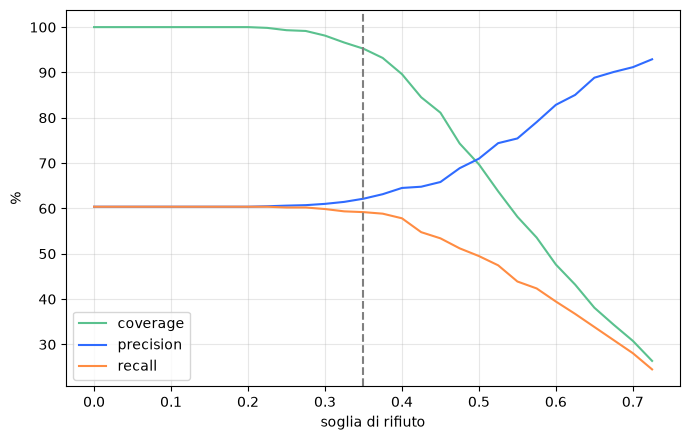

  soglia   coverage   precision    recall
    0.35      95.2%      62.14%     59.2%
    0.45      81.1%      65.83%     53.4%
    0.50      69.7%      70.98%     49.5%
    0.60      47.6%      82.86%     39.5%


In [15]:
righe = []
for s in np.arange(0.0, 0.75, 0.025):
    acc_ = somiglianza >= s
    k = int(acc_.sum())
    if k == 0:
        continue
    righe.append((s, 100*k/len(yte),
                  100*(scelta[acc_] == yte[acc_]).float().mean().item(),
                  100*((scelta == yte) & acc_).float().sum().item()/len(yte)))
cur = pd.DataFrame(righe, columns=["soglia", "coverage", "precision", "recall"])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(cur.soglia, cur.coverage,  label="coverage",  color="#5ac18e")
ax.plot(cur.soglia, cur.precision, label="precision", color="#2f6bff")
ax.plot(cur.soglia, cur.recall,    label="recall",    color="#ff8c42")
ax.axvline(SOGLIA_RIFIUTO, ls="--", c="gray")
ax.set_xlabel("soglia di rifiuto"); ax.set_ylabel("%"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"{'soglia':>8} {'coverage':>10} {'precision':>11} {'recall':>9}")
for s_ in (0.35, 0.45, 0.50, 0.60):
    r_ = cur.iloc[(cur.soglia - s_).abs().argmin()]
    print(f"{r_.soglia:>8.2f} {r_.coverage:>9.1f}% {r_.precision:>10.2f}% {r_.recall:>8.1f}%")

La soglia va ritarata quando il catalogo cresce: la distribuzione delle similarità cambia
all'aumentare del numero di prototipi.

## Fusione con il vettore numerico

Due punti di iniezione. Prima del bottleneck, il vettore numerico può interagire con le
feature visive nella proiezione. Dopo il bottleneck, agisce solo sul confine di decisione.

Il vettore ha 12 componenti contro le 1280 dell'embedding. Senza standardizzazione e
proiezione il suo contributo all'ingresso è marginale per ragioni dimensionali, prima
ancora che informative: qui viene standardizzato e proiettato a 32 componenti da un MLP a
due strati.

Wang, Tran e Feiszli (CVPR 2020) documentano che la migliore rete a modalità singola supera
quella multimodale in modo consistente, per via delle diverse velocità di overfitting delle
due modalità. Un risultato negativo nella cella seguente rientra fra gli esiti attesi.

In [16]:
# ============================================================================
# PUNTO DI VARIAZIONE 3     "dopo_bottleneck" oppure "prima_bottleneck"
PUNTO_DI_INIEZIONE = "dopo_bottleneck"
# ============================================================================

iniez = "dopo" if PUNTO_DI_INIEZIONE == "dopo_bottleneck" else "prima"

a_img, s_img, p_img = su_tre_seed(lambda: Head(1280, arcface=True, margine=0.5))
a_fus, s_fus, p_fusa = su_tre_seed(
    lambda: Head(1280, dim_geo=Gt.shape[1], arcface=True, margine=0.5, iniezione=iniez),
    Xtr, Gtr)

print(f"solo immagine                        accuracy {a_img:6.2f}%   sd {s_img:.2f}")
print(f"immagine + {Gt.shape[1]} misure ({PUNTO_DI_INIEZIONE:<17}) accuracy {a_fus:6.2f}%   sd {s_fus:.2f}")
print(f"\ndifferenza media: {a_fus - a_img:+.2f} punti")
confronta("confronto sul seed 0", p_fusa, p_img)

solo_img = Head(1280, arcface=True, margine=0.5); allena(solo_img, Xtr, ytr)
p_img = predici(solo_img, Xte)

solo immagine                        accuracy  67.63%   sd 0.35
immagine + 12 misure (dopo_bottleneck  ) accuracy  67.80%   sd 0.56

differenza media: +0.17 punti
confronto sul seed 0                          67.01%   +22 -28  disaccordi  50  p=0.480   entro il rumore


---

# Passo 4 — Valutazione

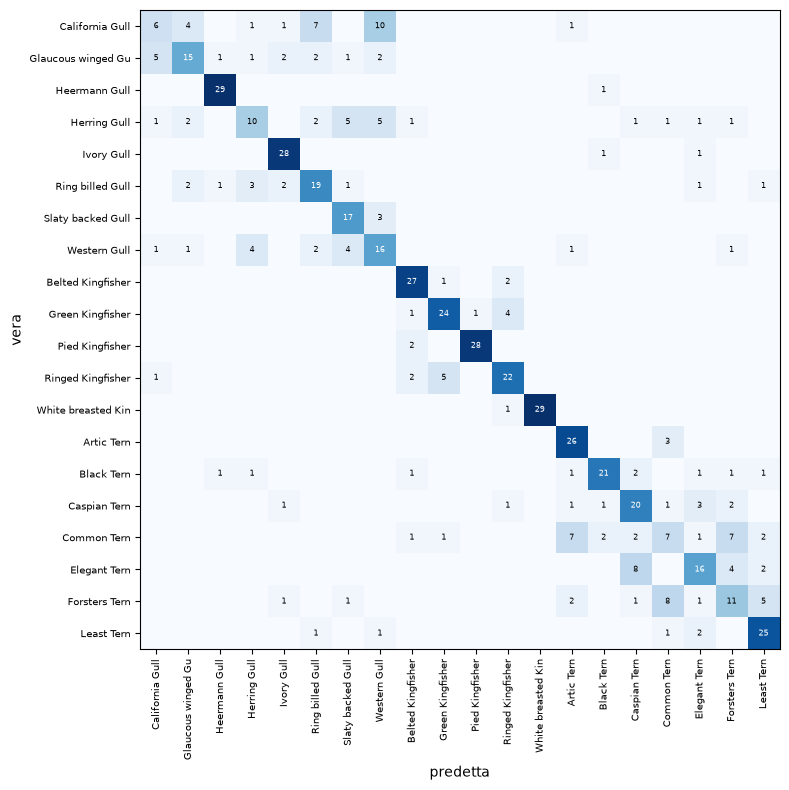

In [17]:
from sklearn.metrics import confusion_matrix

M = confusion_matrix(yte, p_img, labels=range(NCLASSI))
etich = [n.split(".")[1].replace("_", " ")[:18] for n in nomi_classe]

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(M, cmap="Blues")
ax.set_xticks(range(NCLASSI)); ax.set_xticklabels(etich, rotation=90, fontsize=7)
ax.set_yticks(range(NCLASSI)); ax.set_yticklabels(etich, fontsize=7)
ax.set_xlabel("predetta"); ax.set_ylabel("vera")
for i in range(NCLASSI):
    for j in range(NCLASSI):
        if M[i, j]:
            ax.text(j, i, M[i, j], ha="center", va="center", fontsize=6,
                    color="white" if M[i, j] > M.max()/2 else "black")
plt.tight_layout(); plt.show()

In [18]:
# Errore gerarchico: la confusione fra generi ha costo diverso da quella fra specie.
def genere(nome):
    return "Gull" if "Gull" in nome else "Tern" if "Tern" in nome else "Kingfisher"

gen = np.array([genere(n) for n in nomi_classe])
gv, gp = gen[yte.numpy()], gen[p_img.numpy()]
giuste, genere_ok = (p_img == yte).float().mean().item(), (gv == gp).mean()

print(f"specie corretta                     {100*giuste:6.2f}%")
print(f"genere corretto                     {100*genere_ok:6.2f}%")
print(f"genere corretto, specie sbagliata   {100*(genere_ok-giuste):6.2f}%")
print(f"genere sbagliato                    {100*(1-genere_ok):6.2f}%")
print()
with torch.no_grad():
    logit = solo_img(Xte)
for k in (1, 3, 5):
    topk = logit.topk(k, dim=1).indices
    print(f"top-{k} accuracy: {100*(topk == yte[:, None]).any(1).float().mean().item():6.2f}%")

specie corretta                      67.35%
genere corretto                      95.75%
genere corretto, specie sbagliata    28.40%
genere sbagliato                      4.25%

top-1 accuracy:  67.35%
top-3 accuracy:  86.22%
top-5 accuracy:  90.48%


## Significatività di una differenza

L'intervallo di confidenza binomiale descrive l'incertezza sull'accuracy di un modello
isolato. Il confronto fra due modelli valutati sullo stesso test set richiede il test di
McNemar, che considera le sole immagini su cui i due modelli divergono ed è già applicato
da `confronta` in ogni confronto di questo notebook.

Il test ha 588 immagini, quindi una singola immagine vale 0,17 punti di accuracy.

## Grad-CAM

La libreria produce la mappa per una classe specifica tramite `ClassifierOutputTarget`,
quindi consente di richiedere anche la mappa di una classe diversa dalla predetta.

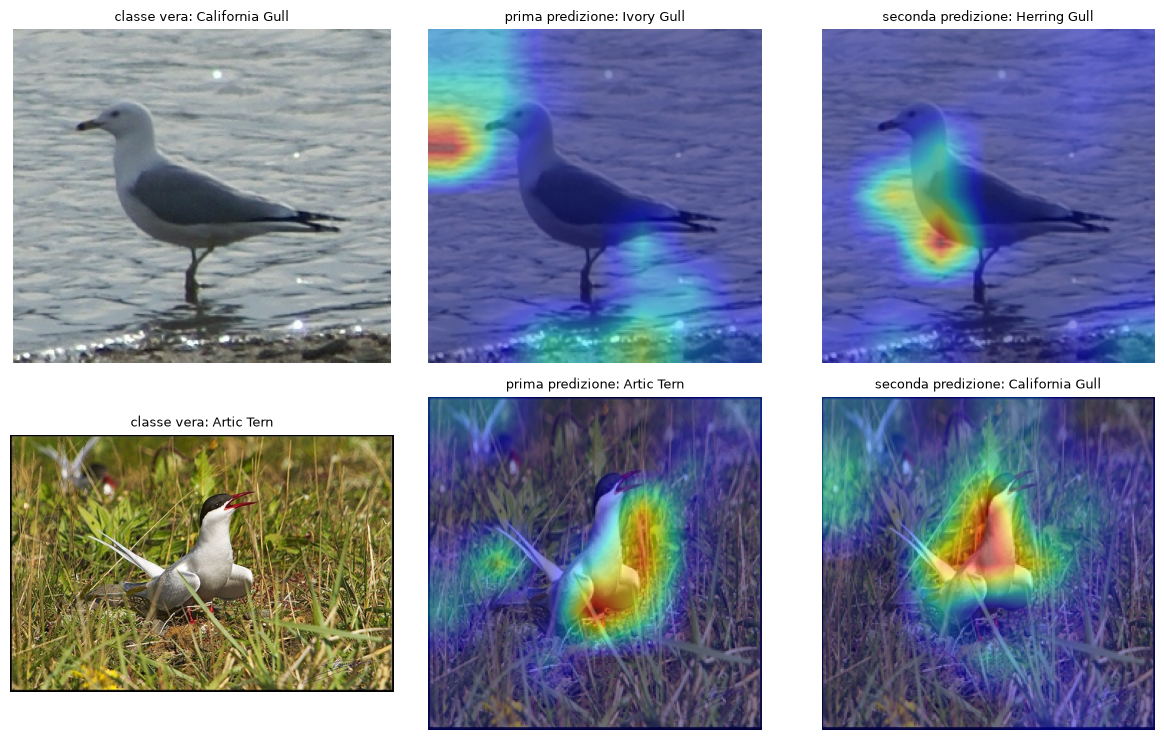

In [19]:
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    !pip install -q grad-cam
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class Completo(nn.Module):
    def __init__(self, head):
        super().__init__()
        self.features, self.pool, self.head = rete.features, rete.avgpool, head
    def forward(self, x):
        return self.head(torch.flatten(self.pool(self.features(x)), 1))

intero = Completo(solo_img).eval().cpu()
# Grad-CAM richiede i gradienti rispetto alle attivazioni. Il backbone e' congelato,
# quindi il grafo va riabilitato: nessun peso viene aggiornato.
for q in intero.parameters():
    q.requires_grad_(True)
cam = GradCAM(model=intero, target_layers=[intero.features[-1]])

sel = [dati[(dati.train == 0) & dati.nome.str.contains(g)].iloc[0] for g in ("Gull", "Tern")]
fig, assi = plt.subplots(2, 3, figsize=(12, 7.5))
for riga, r in zip(assi, sel):
    im = Image.open(D/"images"/r.file).convert("RGB")
    x = prep(im).unsqueeze(0)
    with torch.no_grad():
        top = intero(x)[0].topk(2).indices.tolist()
    riga[0].imshow(im); riga[0].set_title(f"classe vera: {etich[r.y]}", fontsize=9)
    for a, k, tit in zip(riga[1:], top, ("prima predizione", "seconda predizione")):
        m_ = cam(input_tensor=x, targets=[ClassifierOutputTarget(k)])[0]
        a.imshow(im.resize((224, 224))); a.imshow(m_, cmap="jet", alpha=0.45)
        a.set_title(f"{tit}: {etich[k]}", fontsize=9)
    for a in riga: a.axis("off")
plt.tight_layout(); plt.show()

In [20]:
# Class sensitivity: sovrapposizione fra la mappa della prima e della seconda classe.
rng = np.random.default_rng(0)
campione = rng.choice(np.where(dati.train.values == 0)[0], size=60, replace=False)
accordi = []
for j in campione:
    x = prep(Image.open(D/"images"/dati.file.iloc[j]).convert("RGB")).unsqueeze(0)
    with torch.no_grad():
        top = intero(x)[0].topk(2).indices.tolist()
    m1 = cam(input_tensor=x, targets=[ClassifierOutputTarget(top[0])])[0]
    m2 = cam(input_tensor=x, targets=[ClassifierOutputTarget(top[1])])[0]
    k = max(1, int(0.05 * m1.size))
    a = set(np.argpartition(m1.ravel(), -k)[-k:])
    b = set(np.argpartition(m2.ravel(), -k)[-k:])
    accordi.append(len(a & b) / k)
accordi = np.array(accordi)
print("sovrapposizione sul 5% di pixel a salienza massima, prima contro seconda classe:")
print(f"  media    {100*accordi.mean():.1f}%")
print(f"  mediana  {100*np.median(accordi):.1f}%")
print(f"  campioni sopra il 50%: {100*(accordi >= .5).mean():.0f}%")

sovrapposizione sul 5% di pixel a salienza massima, prima contro seconda classe:
  media    4.4%
  mediana  0.0%
  campioni sopra il 50%: 2%


La letteratura documenta per la famiglia CAM una scarsa sensibilità alla classe: mappe
quasi identiche al variare della classe target. La misura sopra mostra che il modello in
esame non presenta questo comportamento. Il controllo va ripetuto su ogni modello, perché
il risultato dipende dall'architettura e dal training.

Grad-CAM supera i sanity check di Adebayo et al. (NeurIPS 2018). Guided Backpropagation e
Guided Grad-CAM li falliscono: producono mappe di aspetto plausibile anche su reti con pesi
casuali.

Restano due limiti operativi. La mappa nasce alla risoluzione dell'ultimo blocco
convoluzionale, 7×7 per un ingresso 224×224, quindi ogni cella copre 32×32 pixel: nel
fine-grained la regione discriminante può essere più piccola di una cella. E sul modello
fuso la mappa non copre il ramo numerico, misurato nella cella seguente.

In [21]:
# Contributo delle due modalita': con due input le combinazioni sono quattro
# e i valori di Shapley si calcolano direttamente.
contributi = {"niente": 100.0 / NCLASSI}
print(f"  {'nessun input':22} {contributi['niente']:6.2f}%   riferimento casuale")

mi = Head(1280, arcface=True, margine=0.5); allena(mi, Xtr, ytr)
contributi["solo immagine"] = accuracy(predici(mi, Xte), yte)
print(f"  {'solo immagine':22} {contributi['solo immagine']:6.2f}%")

mg = Head(Gt.shape[1], arcface=True, margine=0.5); allena(mg, Gtr, ytr)
contributi["solo misure"] = accuracy(predici(mg, Gte), yte)
print(f"  {'solo misure':22} {contributi['solo misure']:6.2f}%")

mf = Head(1280, dim_geo=Gt.shape[1], arcface=True, margine=0.5, iniezione="dopo")
allena(mf, Xtr, ytr, Gtr)
contributi["immagine + misure"] = accuracy(predici(mf, Xte, Gte), yte)
print(f"  {'immagine + misure':22} {contributi['immagine + misure']:6.2f}%")

b_ = contributi["niente"]
sh_img = 0.5*(contributi["solo immagine"]-b_) + 0.5*(contributi["immagine + misure"]-contributi["solo misure"])
sh_num = 0.5*(contributi["solo misure"]  -b_) + 0.5*(contributi["immagine + misure"]-contributi["solo immagine"])
print(f"\nvalore di Shapley, immagine: {sh_img:6.2f} punti")
print(f"valore di Shapley, misure:   {sh_num:6.2f} punti")
print(f"incremento delle misure sopra la sola immagine: "
      f"{contributi['immagine + misure'] - contributi['solo immagine']:+.2f} punti")

  nessun input             5.00%   riferimento casuale


  solo immagine           67.35%


  solo misure             22.11%


  immagine + misure       67.86%

valore di Shapley, immagine:  54.05 punti
valore di Shapley, misure:     8.81 punti
incremento delle misure sopra la sola immagine: +0.51 punti


Le misure hanno un valore di Shapley di alcuni punti e un incremento marginale sopra la
sola immagine prossimo allo zero: l'informazione che portano è in larga parte già presente
nell'immagine. Nel caso ZCS la misura strumentale non è ricavabile dall'immagine, quindi
l'incremento marginale atteso è diverso. Il criterio generale: una feature numerica è utile
quando porta informazione che l'immagine non consente di ricostruire.

Nessuna mappa di salienza fornisce questi valori. Grad-CAM opera sul ramo convoluzionale e
non copre il ramo numerico.

---

# Passo 5 — Produzione e vincoli

**Crescita del catalogo.** Con i prototipi l'inserimento di una categoria richiede il
calcolo di un vettore. Con un classificatore chiuso richiede una riga di pesi aggiuntiva,
un riaddestramento e una rivalidazione. Su 900 categorie la ricerca esaustiva su indice
esatto occupa meno di mezzo megabyte e resta nell'ordine dei microsecondi: indici
approssimati come FAISS o HNSW diventano rilevanti diversi ordini di grandezza più avanti.

**Preprocessing imposto dalla distribuzione.** Le immagini di questo notebook sono
ricompresse in JPEG qualità 95 per contenere la release sotto i 100 MB. Le dimensioni in
pixel non cambiano, quindi bounding box e coordinate delle parti restano valide, ma il
segnale in ingresso al modello è stato modificato da un vincolo di distribuzione.

**Licenza.** CUB-200-2011 non ha una licenza standard e i suoi termini limitano l'uso a
ricerca e didattica non commerciali. Il dataset compare in questo notebook e non nel PDF
delle slide, che viene ceduto con diritto d'uso commerciale.